# 🌸 Ejercicio: Clasificación de Iris con MLflow

## 🎯 Objetivos del Ejercicio

En este ejercicio práctico aprenderás a:

1. **Trabajar con un problema de clasificación** multiclase
2. **Aplicar MLflow** a un modelo de árbol de decisión
3. **Registrar experimentos** de forma profesional
4. **Evaluar y comparar** diferentes configuraciones
5. **Crear visualizaciones** para clasificación

---

## 🌺 El Dataset Iris

El **Iris Dataset** es uno de los datasets más famosos en Machine Learning, introducido por Ronald Fisher en 1936.

### 📊 Características del Dataset

| Aspecto | Descripción |
|---------|-------------|
| **Muestras** | 150 flores (50 por clase) |
| **Características** | 4 medidas físicas (cm) |
| **Clases** | 3 especies de iris |
| **Tipo** | Clasificación multiclase |
| **Dificultad** | ⭐⭐ (Principiante) |

### 🌸 Las 3 Especies de Iris

1. **Iris Setosa** (Clase 0)
2. **Iris Versicolor** (Clase 1)
3. **Iris Virginica** (Clase 2)

### 📏 Las 4 Características

1. **Sepal Length** (Longitud del sépalo)
2. **Sepal Width** (Ancho del sépalo)
3. **Petal Length** (Longitud del pétalo)
4. **Petal Width** (Ancho del pétalo)

---

## 🎯 Tu Misión

Construir un **Árbol de Decisión** que pueda clasificar correctamente las especies de iris basándose en sus medidas físicas, y documentar todo el proceso con MLflow.

---

## 🚀 ¡Empecemos!

In [0]:
import mlflow
import warnings
warnings.filterwarnings('ignore')


mlflow.set_tracking_uri("databricks")
mlflow.set_registry_uri("databricks")

# ⚠️ IMPORTANTE: Cambia esto por tu email de Databricks
email = 'alejandroldz2004@gmail.com'  # Ejemplo: 'nombre.apellido@ejemplo.com'

# Validar que el email no esté vacío
if not email:
    print("⚠️  ADVERTENCIA: Debes configurar tu email antes de continuar")
    print("   Cambia la variable 'email' por tu email de Databricks")
else:
    # Configurar el experimento
    experiment_name = f"/Users/{email}/4-ejercicio-the-irish"
    mlflow.set_experiment(experiment_name)
    
    print("=" * 60)
    print("✅ MLflow configurado correctamente")
    print("=" * 60)
    print(f"📊 Experimento: {experiment_name}")
    print(f"🌸 Dataset: Iris (Clasificación)")
    print(f"🤖 Modelo: Decision Tree Classifier")
    print("=" * 60)

✅ MLflow configurado correctamente
📊 Experimento: /Users/alejandroldz2004@gmail.com/4-ejercicio-the-irish
🌸 Dataset: Iris (Clasificación)
🤖 Modelo: Decision Tree Classifier


## ⚙️ Paso 1: Configuración de MLflow

Configuramos el experimento donde se registrarán todas las ejecuciones.

**🔴 IMPORTANTE**: Cambia el email vacío por tu email de Databricks.

## 📚 Paso 2: Importar Librerías

Importamos todas las herramientas necesarias para clasificación.

In [0]:
# Librerías principales
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MLflow para tracking
import mlflow
import mlflow.sklearn

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import datasets
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix,
    classification_report
)

# Configuración de visualización
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

print("✅ Todas las librerías importadas correctamente")
print("   - MLflow: Listo para tracking")
print("   - Scikit-learn: Modelos y métricas")
print("   - Matplotlib & Seaborn: Visualizaciones")

✅ Todas las librerías importadas correctamente
   - MLflow: Listo para tracking
   - Scikit-learn: Modelos y métricas
   - Matplotlib & Seaborn: Visualizaciones


## 🌺 Paso 3: Cargar y Explorar el Dataset Iris

Cargaremos el famoso dataset de flores Iris y exploraremos sus características.

In [0]:
# TODO: Carga el dataset Iris y explora su estructura.
# Pistas:
# - Usa datasets.load_iris()
# - Crea un DataFrame con dataset.data y dataset.feature_names
# - Añade la columna target/especie
# - Muestra shape, clases, primeras filas y estadísticas descriptivas

dataset = datasets.load_iris()
df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
df['species'] = dataset.target

print('Shape:', df.shape)
print('Clases:', dataset.target_names.tolist())
print(df.head())
print(df.describe())


Shape: (150, 5)
Clases: ['setosa', 'versicolor', 'virginica']
   sepal length (cm)  sepal width (cm)  ...  petal width (cm)  species
0                5.1               3.5  ...               0.2        0
1                4.9               3.0  ...               0.2        0
2                4.7               3.2  ...               0.2        0
3                4.6               3.1  ...               0.2        0
4                5.0               3.6  ...               0.2        0

[5 rows x 5 columns]
       sepal length (cm)  sepal width (cm)  ...  petal width (cm)     species
count         150.000000        150.000000  ...        150.000000  150.000000
mean            5.843333          3.057333  ...          1.199333    1.000000
std             0.828066          0.435866  ...          0.762238    0.819232
min             4.300000          2.000000  ...          0.100000    0.000000
25%             5.100000          2.800000  ...          0.300000    0.000000
50%             5.8000

### 📊 Visualización Exploratoria del Dataset

Visualicemos las relaciones entre las características para entender mejor los datos.

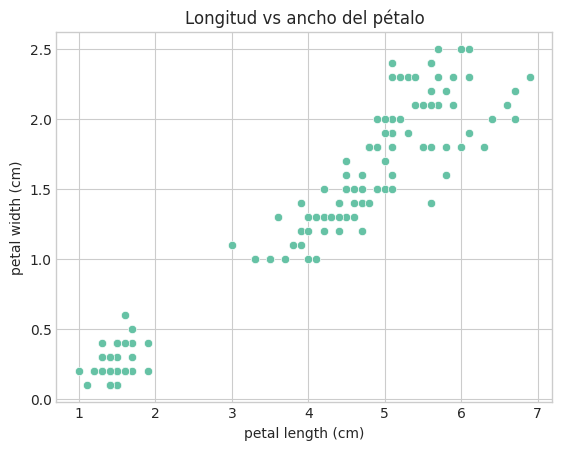

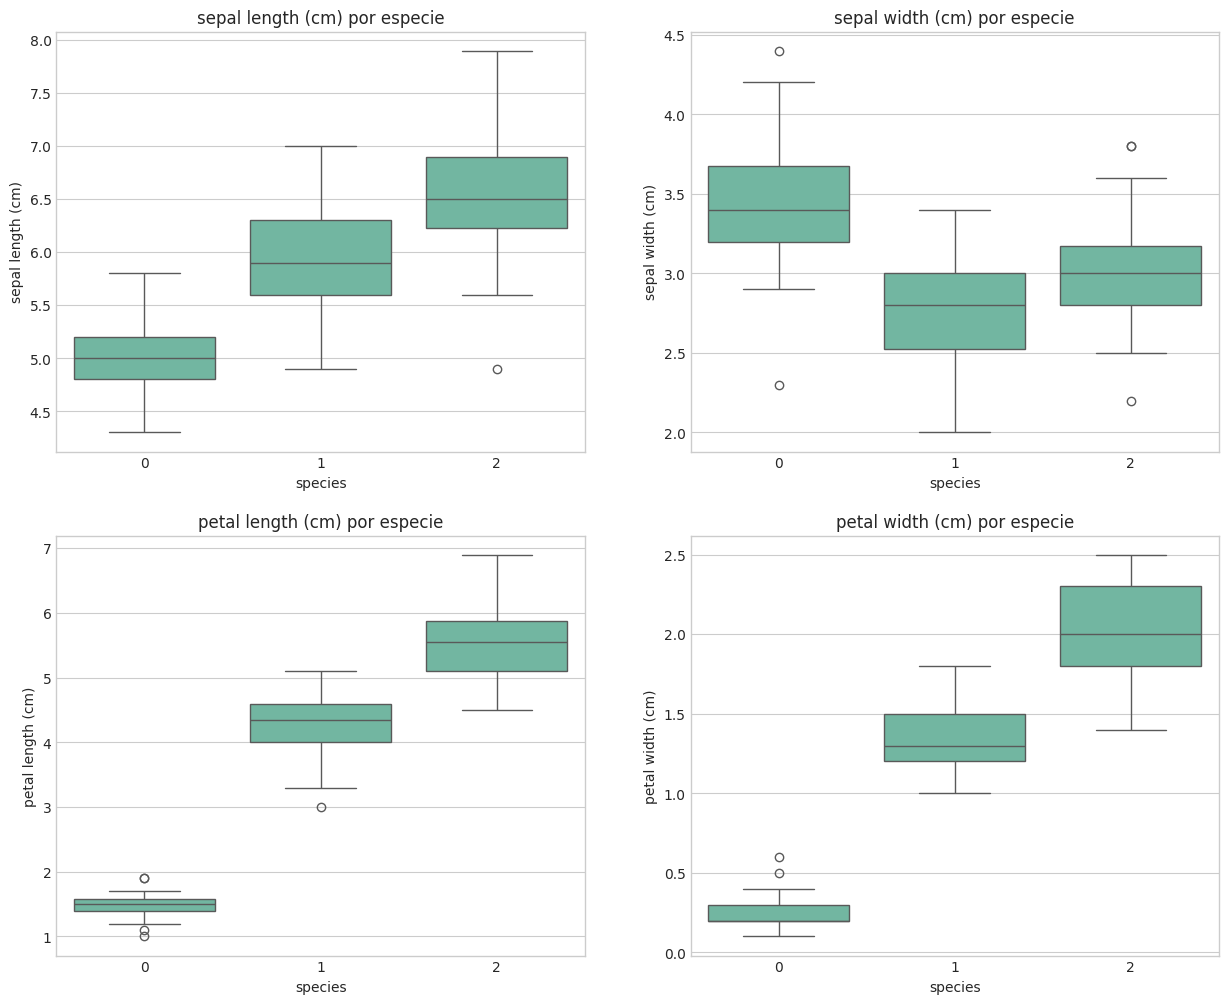

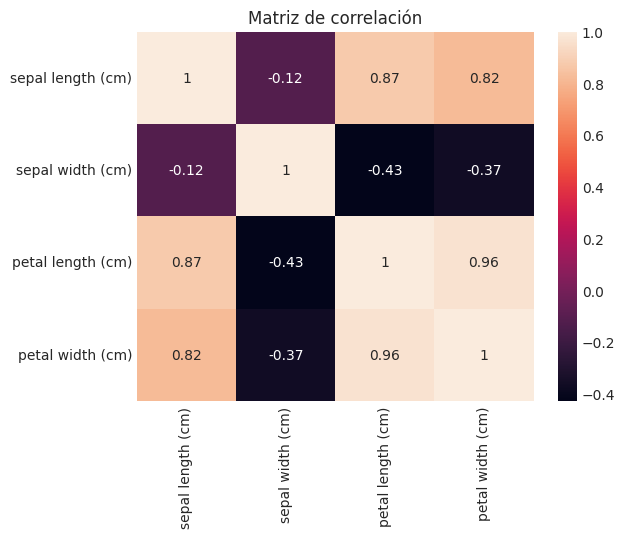

In [0]:
# TODO: Crea visualizaciones exploratorias del dataset Iris.
# Ideas:
# - Relación entre longitud/ancho del pétalo por especie
# - Distribución de características por especie
# - Boxplots por especie
# - Matriz de correlación

sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)')
plt.title('Longitud vs ancho del pétalo')
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
for i, col in enumerate(df.columns[:-1]):
    ax = axes[i // 2, i % 2]
    sns.boxplot(data=df, x='species', y=col, ax=ax)
    ax.set_title(f'{col} por especie')
plt.show()

corr = df.drop(columns='species').corr()
sns.heatmap(corr, annot=True)
plt.title('Matriz de correlación')
plt.show()

# TODO: Escribe tus observaciones clave sobre separabilidad y correlaciones.
# Hay una clara relacion entre el petal length y petal width. Por otro lado, los boxplots muestran la presencia de algunos posibles outliers y las distintas
# características que hay entre especies. En cuanto a la matriz de correlacion, encontramos que las características estan muy correlacionadas entre sí (excepto sepal width y length)


## 🔀 Paso 4: Preparar los Datos

Dividimos el dataset en conjuntos de entrenamiento y prueba.

In [0]:
# TODO: Separa características (X) y etiquetas (y).
X = df[dataset.feature_names]
y = df['species']

# TODO: Divide el dataset en entrenamiento y prueba.
# Pistas:
# - Usa train_test_split
# - Reserva una parte para test
# - Usa random_state para reproducibilidad
# - Considera stratify=y para mantener la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# TODO: Comprueba tamaños y distribución de clases en cada conjunto.
print('Train:', X_train.shape)
print('Test:', X_test.shape)
print('Distribución y_train:', y_train.value_counts())
print('Distribución y_test:', y_test.value_counts())


Train: (120, 4)
Test: (30, 4)
Distribución y_train: species
0    40
2    40
1    40
Name: count, dtype: int64
Distribución y_test: species
0    10
2    10
1    10
Name: count, dtype: int64


## 🌳 Paso 5: Entrenar Árbol de Decisión con MLflow

Ahora entrenaremos un modelo de **Decision Tree** y registraremos todo con MLflow.

### 🔑 Hiperparámetros del Árbol de Decisión

- **max_depth**: Profundidad máxima del árbol (evita overfitting)
- **max_features**: Número máximo de características a considerar por split
- Valores más altos = modelo más complejo = mayor riesgo de overfitting

2026/09/23 22:04:48 WARNING mlflow.tracking.context.registry: Encountered unexpected error during resolving tags: An error occurred while calling o1771.extraContext. Trace:
py4j.security.Py4JSecurityException: Method public scala.collection.immutable.Map com.databricks.backend.common.rpc.CommandContext.extraContext() is not whitelisted on class class com.databricks.backend.common.rpc.CommandContext
	at py4j.security.WhitelistingPy4JSecurityManager.checkCall(WhitelistingPy4JSecurityManager.java:473)
	at py4j.Gateway.invoke(Gateway.java:305)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.$anonfun$invokeMethod$1(InstrumentedCallCommand.scala:19)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke(InstrumentedPy4jCommand.scala:28)
	at com.databricks.backend.daemon.driver.InstrumentedPy4jCommand.instrumentedInvoke$(InstrumentedPy4jCommand.scala:18)
	at com.databricks.backend.daemon.driver.InstrumentedCallCommand.instrumentedInvoke(Instrument

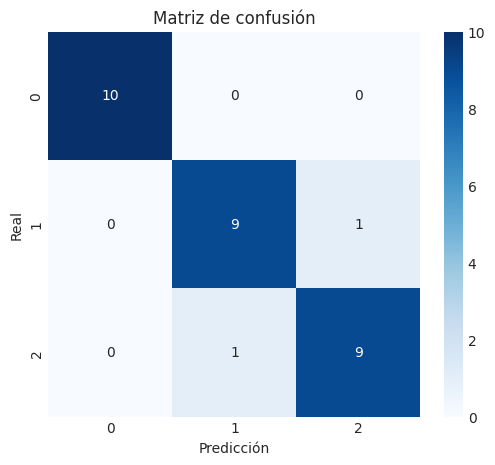

Accuracy test: 0.933
F1 macro: 0.933
CV mean accuracy: 0.940


In [0]:
# ========================================
# TODO: ENTRENAMIENTO CON MLFLOW
# ========================================

# TODO: Activa autologging de MLflow.

mlflow.sklearn.autolog()

# TODO: Inicia un run con un nombre descriptivo.
with mlflow.start_run(run_name='Decision Tree - Iris Classifier') as run:
    # TODO: Define hiperparámetros del árbol.
    max_depth = 3
    max_features = 'sqrt'
    random_state = 42

    # TODO: Crea y entrena DecisionTreeClassifier.
    dt = DecisionTreeClassifier(
        max_depth=max_depth,
        max_features=max_features,
        random_state=random_state
    )
    dt.fit(X_train, y_train)

    # TODO: Genera predicciones para train y test.
    y_pred_train = dt.predict(X_train)
    y_pred_test = dt.predict(X_test)

    # TODO: Calcula métricas de clasificación.
    accuracy_test = accuracy_score(y_test, y_pred_test)
    precision_test = precision_score(y_test, y_pred_test, average='weighted')
    recall_test = recall_score(y_test, y_pred_test, average='weighted')
    f1_test = f1_score(y_test, y_pred_test,average='weighted')

    # TODO: Evalúa con cross-validation.
    cv_scores = cross_val_score(dt, X, y, cv=5)

    # TODO: Registra métricas/parámetros relevantes en MLflow si no quedan registrados automáticamente.
    mlflow.log_param('max_depth', max_depth)
    mlflow.log_param('max_features', max_features)
    mlflow.log_param('random_state', random_state)
    mlflow.log_metric('accuracy_test', accuracy_test)
    mlflow.log_metric('precision_test', precision_test)
    mlflow.log_metric('recall_test', recall_test)
    mlflow.log_metric('f1_test', f1_test)
    mlflow.log_metric('cv_mean_accuracy', cv_scores.mean())

    # TODO: Visualiza matriz de confusión y, opcionalmente, el árbol.
    cm = confusion_matrix(y_test, y_pred_test)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Matriz de confusión')
    plt.ylabel('Real')
    plt.xlabel('Predicción')
    plt.show()

    # TODO: Escribe una breve interpretación de los resultados.
    print(f'Accuracy test: {accuracy_test:.3f}')
    print(f'F1 macro: {f1_test:.3f}')
    print(f'CV mean accuracy: {cv_scores.mean():.3f}')

# El árbol separa bien las clases, aunque hay un par de fallos que habría que revisar, pero el modelo generaliza adecuadamente


%md
## 🎯 Reflexión del Ejercicio

Completa esta sección cuando termines el notebook.

### ✅ Comprueba que has trabajado

1. [ ] Exploración del dataset Iris
2. [ ] Separación train/test
3. [ ] Entrenamiento de un Árbol de Decisión
4. [ ] Evaluación con métricas de clasificación
5. [ ] Registro del experimento en MLflow
6. [ ] Interpretación de resultados

---

## 📚 Conceptos Clave - Clasificación

### 🎯 Métricas de Clasificación

| Métrica | Descripción | Cuándo Usarla |
|---------|-------------|---------------|
| **Accuracy** | % de predicciones correctas | Clases balanceadas |
| **Precision** | % de positivos correctos | Importante evitar falsos positivos |
| **Recall** | % de positivos encontrados | Importante encontrar todos los positivos |
| **F1-Score** | Media armónica de P y R | Balance entre precisión y recall |

### 🌳 Árbol de Decisión

**TODO: Explica con tus palabras:**
- ¿Qué ventajas tiene un árbol de decisión?

Es fácil de entender e interpretar, por lo que para explicabilidad es muy útil. También puede trabajar con variables numéricas y categóricas, lo que lo hace muy flexible
- ¿Qué riesgos tiene respecto a overfitting?

Cuando el árbol crece demasiado y tiene muchas ramas y hojas, puede aparecer overfitting, por lo que conviene controlar los hiperparámetros adecuadamente

- ¿Cómo interpretarías una matriz de confusión multiclase?

Igual que cuando hay 2 clases, pero habría que calcular las métricas individualmente para cada clase

---

## 🚀 Desafíos Adicionales

### 🎯 Desafío 1: Optimiza los Hiperparámetros

Prueba diferentes configuraciones y encuentra la mejor:

```python
# Experimenta con:
max_depth = [3, 5, 10, None]
max_features = [2, 3, 4, 'sqrt']
min_samples_split = [2, 5, 10]
```

**TODO:** ¿Qué combinación da el mejor balance entre accuracy y overfitting?

Por lo que se muestra, son los siguientes: {'max_depth': 3, 'max_features': 2, 'min_samples_split': 2}

### 🎯 Desafío 2: Implementa Grid Search

Automatiza la búsqueda del mejor modelo con `GridSearchCV`.

### 🎯 Desafío 3: Compara con Otros Modelos

Entrena y compara Random Forest, SVM, KNN o Logistic Regression.

### 🎯 Desafío 4: Análisis de Errores

**TODO:** ¿Qué flores se confunden más y por qué?

Hay solo 2 errores, por lo que no podemos afirmar con seguridad que 2 flores se confunden más fácilmente. En general todas se distinguen bien
### 🎯 Desafío 5: Reducción de Dimensionalidad

Usa PCA para reducir a 2 dimensiones y visualizar límites de decisión.


{'max_depth': 2, 'random_state': 1}
{'max_depth': 2, 'random_state': 1} accuracy= 0.9333333333333333
{'max_depth': 3, 'random_state': 2}
{'max_depth': 3, 'random_state': 2} accuracy= 0.9666666666666667
{'max_depth': 5, 'random_state': 3}
{'max_depth': 5, 'random_state': 3} accuracy= 0.9333333333333333
{'max_depth': 3, 'max_features': 2, 'min_samples_split': 2}
[('tree', 0.9333333333333333), ('knn', 1.0), ('rf', 0.9), ('svc', 0.9666666666666667), ('logreg', 0.9666666666666667)]
Errores: [23 25]


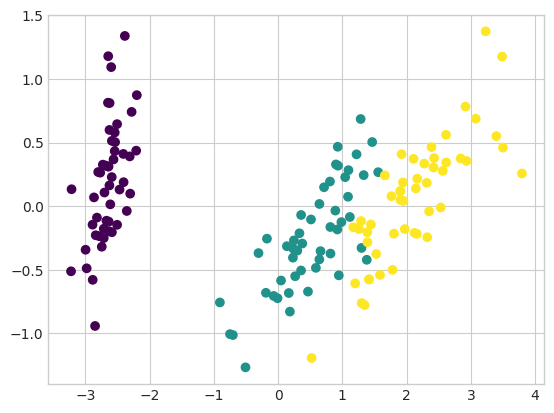

In [0]:
# 🎨 DESAFÍOS OPCIONALES
# Usa este espacio para completar los desafíos del ejercicio.
# ========================================
# TODO: DESAFÍO 1 - Optimización manual
# ========================================
mlflow.sklearn.autolog(silent=True) #gracias a silent=true quito los warning que molestan

configuraciones = [
    {'max_depth': 2, 'random_state': 1},
    {'max_depth': 3, 'random_state': 2},
    {'max_depth': 5, 'random_state': 3}
]
for config in configuraciones:
    print(config)
    modelo = DecisionTreeClassifier(**config)
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    print(config, 'accuracy=', accuracy_score(y_test, pred))

# ========================================
# TODO: DESAFÍO 2 - Grid Search
# ========================================
from sklearn.model_selection import GridSearchCV
param_grid = {'max_depth' : [3, 5, 10], 'max_features' : [2, 3, 4, 'sqrt'], 'min_samples_split' : [2, 5, 10]}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)

# ========================================
# TODO: DESAFÍO 3 - Comparación de modelos
# ========================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
modelos = {'tree': DecisionTreeClassifier(random_state=42), 'knn': KNeighborsClassifier(), 'rf': RandomForestClassifier(random_state=42), 'svc': SVC(), 'logreg': LogisticRegression()}
resultados = []
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    pred = modelo.predict(X_test)
    resultados.append((nombre, accuracy_score(y_test, pred)))
print(resultados)

# ========================================
# TODO: DESAFÍO 4 - Análisis de errores
# ========================================
incorrect_indices = np.where(y_pred_test != y_test)[0]
print('Errores:', incorrect_indices)

# ========================================
# TODO: DESAFÍO 5 - PCA y visualización 2D
# ========================================
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis')
plt.show()
